# 02 - Results

Everything here is read from `results/` and `figures/`, which the scripts in `scripts/` regenerate. No number is typed in by hand.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.width', 200)
from IPython.display import Image, display
R = ROOT / 'results'
F = ROOT / 'figures'

## 1. Calibration (leave-one-meeting-out, 20 FOMC meetings)

In [2]:
cal = pd.read_csv(R / 'calibration_metrics.csv')
cal.pivot(index='method', columns='venue', values='brier').round(4).join(
    cal.pivot(index='method', columns='venue', values='ece').round(4), lsuffix='_brier', rsuffix='_ece')

venue,kalshi_brier,polymarket_brier,pooled_brier,kalshi_ece,polymarket_ece,pooled_ece
method,,,,,,
isotonic,0.0049,0.0048,0.0049,0.0044,0.0050,0.0047
platt,0.0050,0.0049,0.0049,0.0003,0.0005,0.0003
platt_weak_prior,0.0017,0.0021,0.0018,0.0004,0.0009,0.0003
raw,0.0094,0.0088,0.0091,0.0179,0.0138,0.0159


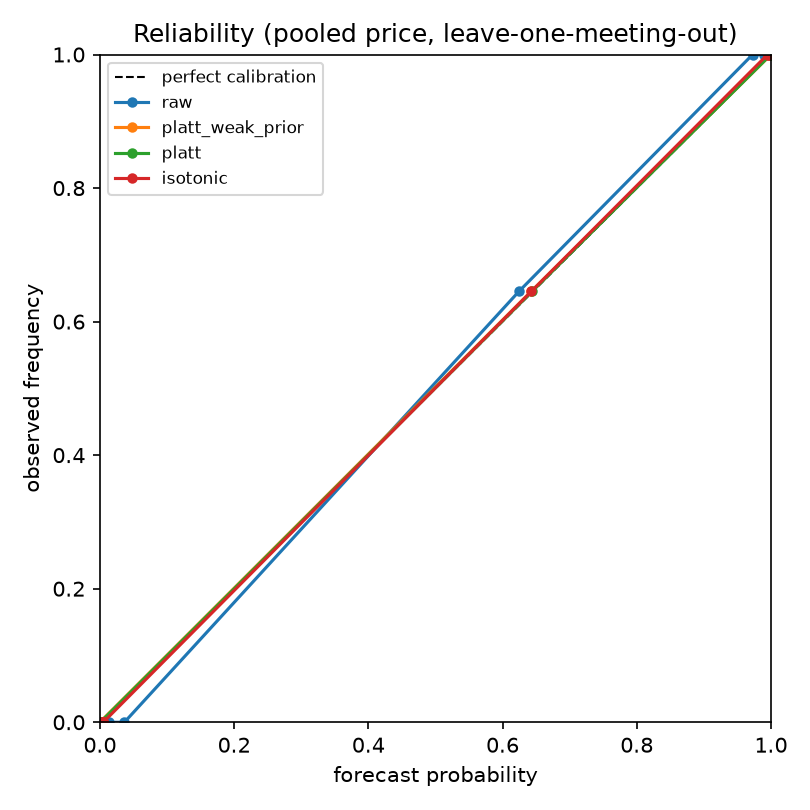

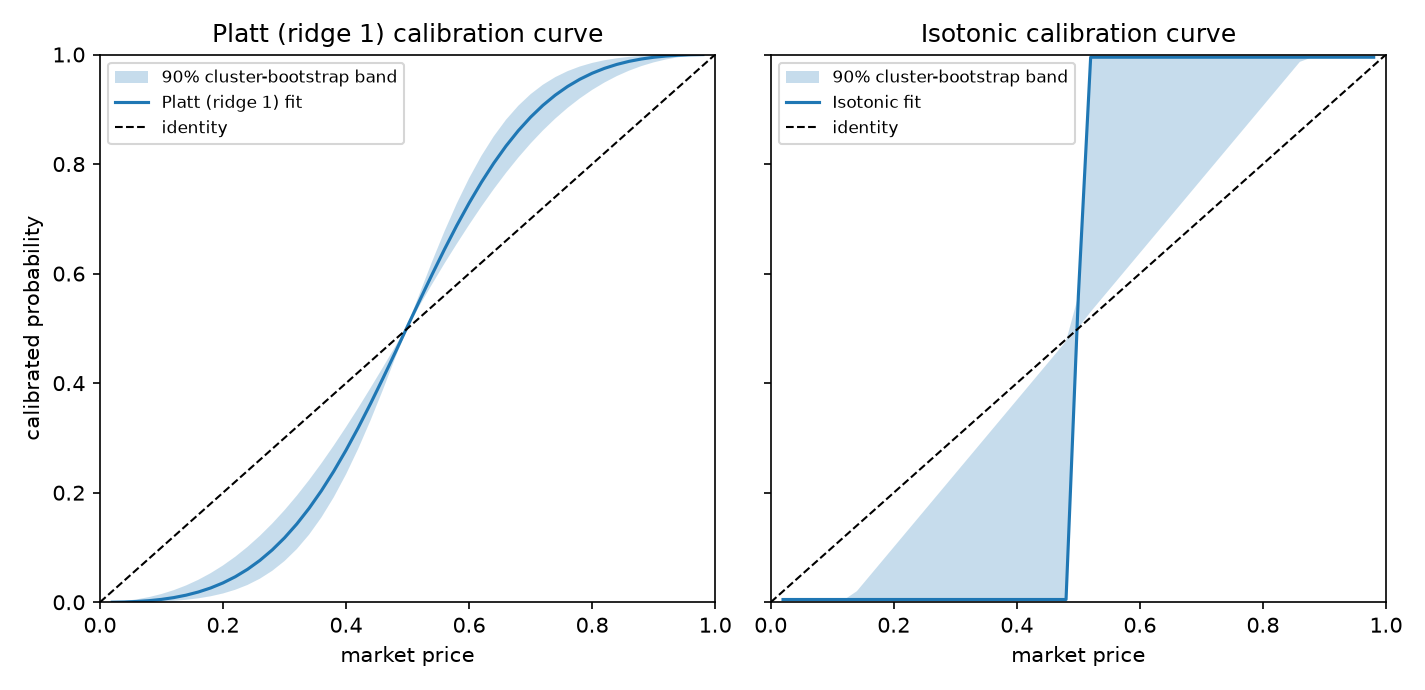

In [3]:
display(Image(F / 'calibration_reliability.png', width=420)); display(Image(F / 'calibration_bootstrap_band.png'))

Only 16 of 246 near-decision snapshots have a price in (0.15, 0.85), so the slope of the calibration curve is identified by very few points; the isotonic fit is essentially a step function.

## 2. Real-vs-noise screen (LazyPredict)

In [4]:
pd.read_csv(R / 'lazypredict_screen.csv').head(8).round(3)

,Model,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
0,QuadraticDiscriminantAnalysis,0.714,0.619,0.646,0.694,0.694,0.714,0.030
1,KNeighborsClassifier,0.686,0.611,0.633,0.676,0.671,0.686,0.077
2,ExtraTreeClassifier,0.671,0.600,0.600,0.664,0.660,0.671,0.073
3,AdaBoostClassifier,0.671,0.588,0.612,0.658,0.652,0.671,0.494
4,Perceptron,0.486,0.588,0.720,0.473,0.686,0.486,0.032
5,NuSVC,0.671,0.588,0.603,0.658,0.652,0.671,0.039
6,SGDClassifier,0.714,0.582,0.629,0.666,0.694,0.714,0.026
7,RandomForestClassifier,0.686,0.574,0.677,0.654,0.654,0.686,0.186


## 3. Backtest (14 FOMC rounds, primary configuration)

In [5]:
pd.read_csv(R / 'backtest_primary.csv', index_col=0).round(4)

,rounds,cum_log_growth,final_wealth,mean_log_return,max_drawdown,sharpe_like,win_rate,worst_round
naive_kelly,14.0,0.2960,1.3444,0.0211,0.0,1.4548,0.5714,0.0
robust_G0,14.0,0.2960,1.3444,0.0211,0.0,1.4548,0.5714,0.0
robust_G0.5,14.0,0.0576,1.0593,0.0041,0.0,1.0727,0.1429,0.0
robust_G1,14.0,0.0000,1.0000,0.0000,0.0,NaN,0.0000,0.0
robust_G2,14.0,0.0000,1.0000,0.0000,0.0,NaN,0.0000,0.0
robust_G3,14.0,0.0000,1.0000,0.0000,0.0,NaN,0.0000,0.0
robust_G5,14.0,0.0000,1.0000,0.0000,0.0,NaN,0.0000,0.0
equal_weight,14.0,0.2929,1.3403,0.0209,0.0,1.4388,0.5714,0.0
random,14.0,0.1895,1.2087,0.0135,0.0,1.4626,0.5714,0.0


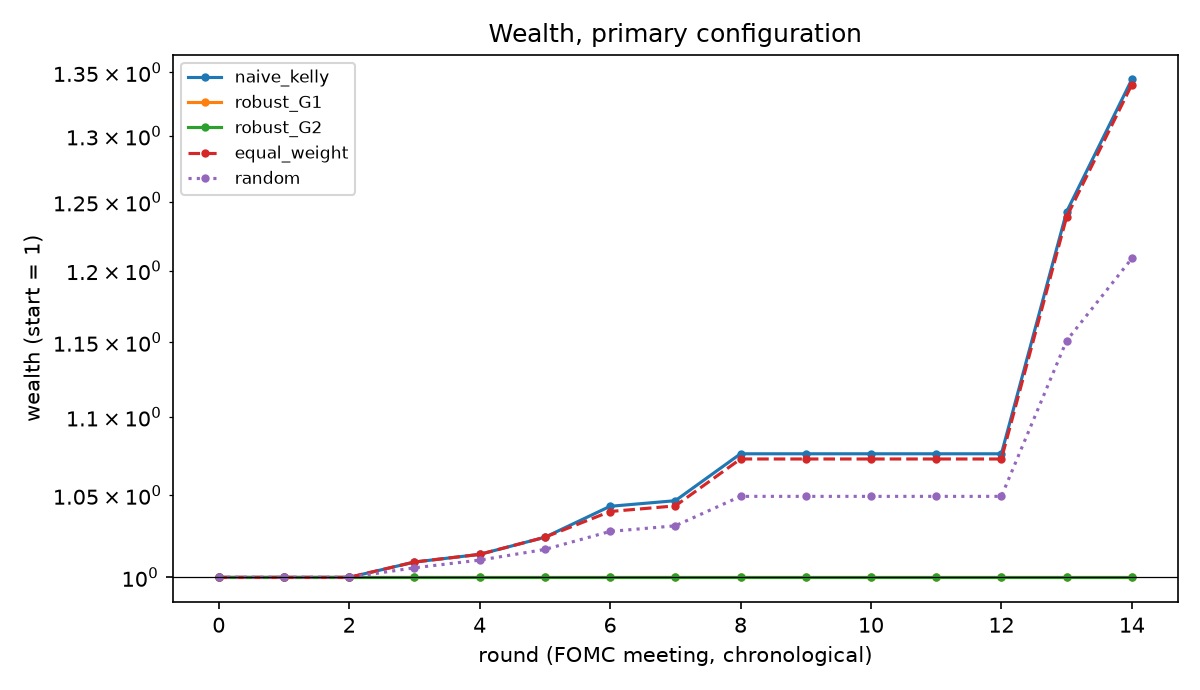

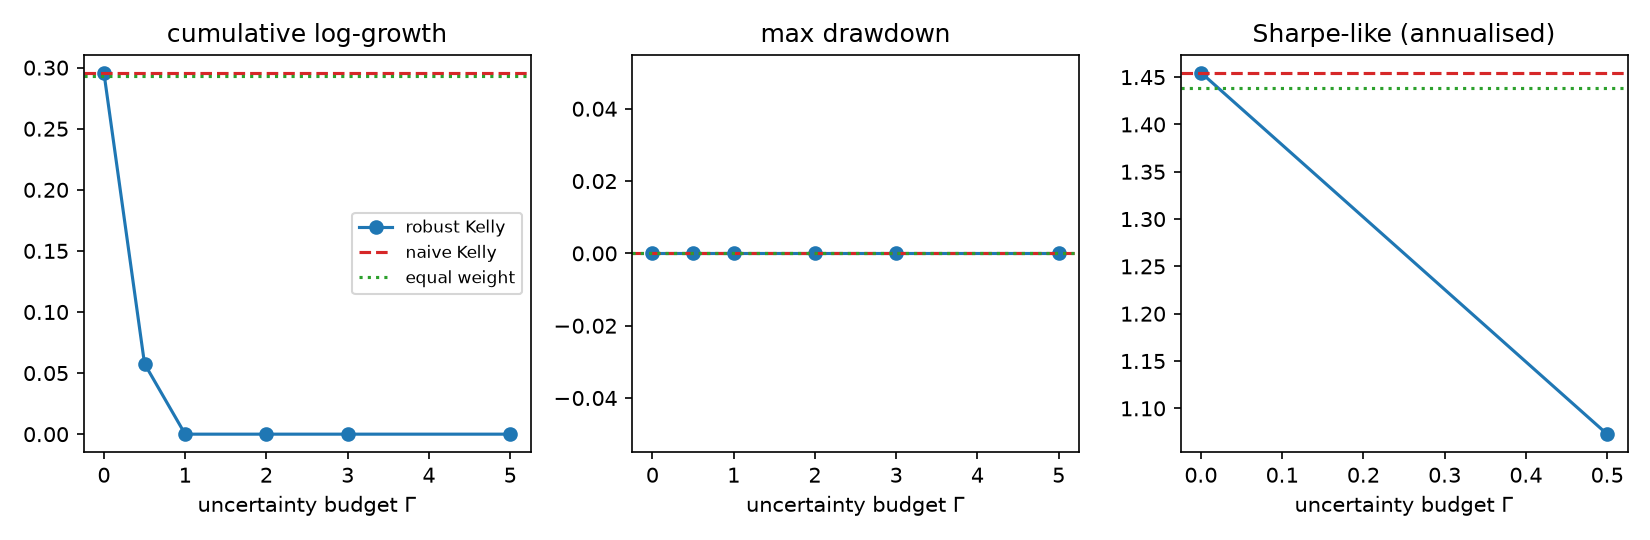

In [6]:
display(Image(F / 'backtest_wealth.png')); display(Image(F / 'backtest_gamma_sensitivity.png'))

### Sensitivity (cumulative log-growth; each column changes one setting)

In [7]:
s = pd.read_csv(R / 'backtest_sensitivity.csv')
s.pivot(index='strategy', columns='variant', values='cum_log_growth').round(3)

variant,bootstrap_intervals,bootstrap_no_weights,budget_0.3,consensus_filter,cost_0.5c,cost_2c,horizon_48h,horizon_72h,isotonic,weak_prior_platt
strategy,,,,,,,,,,
equal_weight,0.293,0.293,0.150,0.0,0.321,0.241,0.440,0.387,0.293,0.293
naive_kelly,0.296,0.296,0.152,0.0,0.324,0.241,0.455,0.395,0.296,0.296
random,0.191,0.191,0.097,0.0,0.208,0.152,0.288,0.252,0.191,0.191
robust_G0,0.296,0.296,0.152,0.0,0.324,0.241,0.455,0.395,0.296,0.296
robust_G1,0.296,0.296,0.000,0.0,0.000,0.000,0.000,0.000,0.293,0.000
robust_G2,0.296,0.296,0.000,0.0,0.000,0.000,0.000,0.000,0.226,0.000
robust_G5,0.296,0.296,0.000,0.0,0.000,0.000,0.000,0.000,0.226,0.000


## 4. Simulation: the price of robustness (known ground truth)

In [8]:
sim = pd.read_csv(R / 'simulation_summary.csv')
sim.pivot(index='strategy', columns='k_bad', values='mean').round(4)

k_bad,0,1,2,4
strategy,,,,
equal_weight,0.0626,0.0601,0.0640,0.0605
naive_kelly,0.0689,0.0536,0.0457,0.0460
oracle_kelly,0.0728,0.0708,0.0738,0.0700
robust_G0,0.0688,0.0535,0.0455,0.0460
robust_G1,0.0647,0.0641,0.0605,0.0545
robust_G2,0.0543,0.0605,0.0659,0.0579
robust_G3,0.0386,0.0502,0.0618,0.0610
robust_G6,0.0151,0.0250,0.0374,0.0506


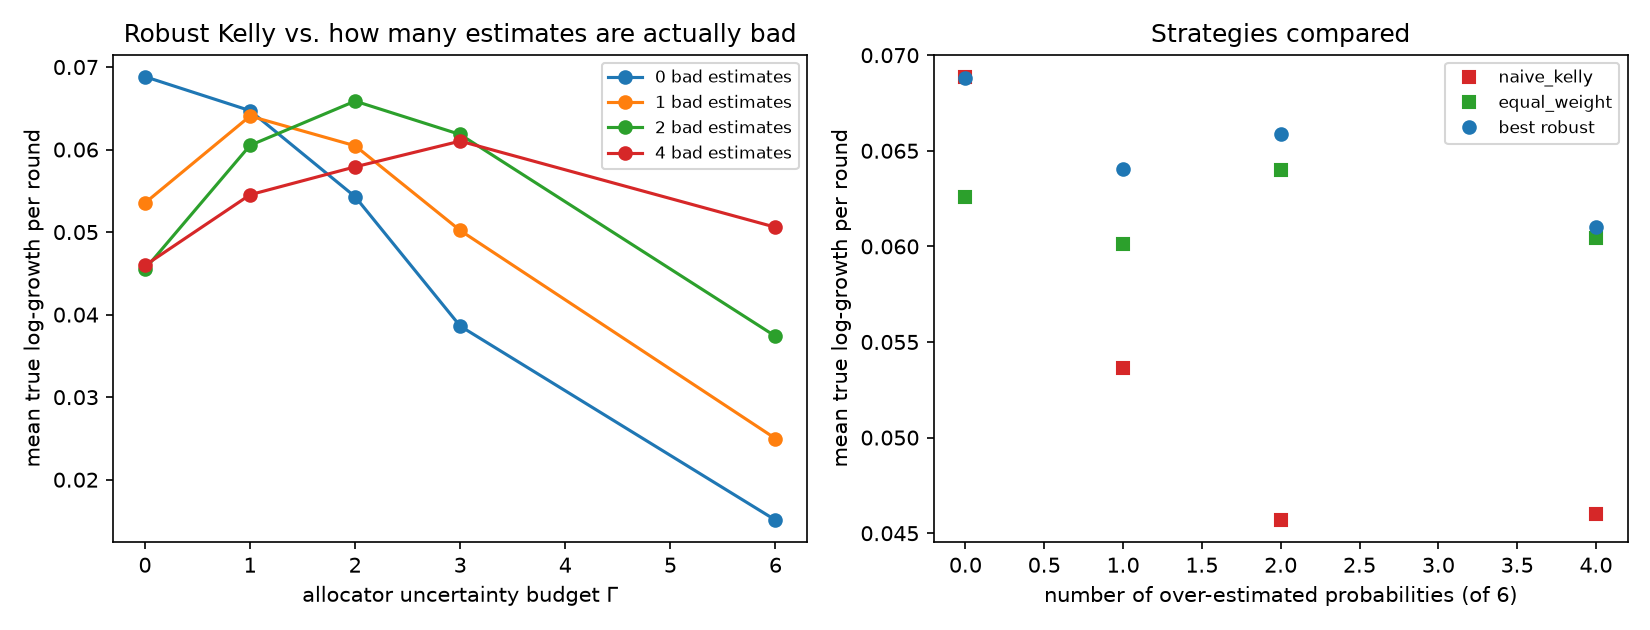

In [9]:
display(Image(F / 'simulation_gamma.png'))